In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load trees dataset

df = pd.read_csv("trees.csv")

# Display first rows

df.head()

,ID,Age,Vol
0,1.1.1,9.67,5.0
1,1.1.1,19.67,38.0
2,1.1.1,29.67,123.0
3,1.1.1,39.67,263.0
4,1.1.1,49.67,400.0


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      1200 non-null   str    
 1   Age     1200 non-null   float64
 2   Vol     1200 non-null   float64
dtypes: float64(2), str(1)
memory usage: 34.8 KB


In [4]:
# Remove duplicate rows

df = df.drop_duplicates()

# Fill missing values

df = df.fillna("Unknown")

df.head()

,ID,Age,Vol
0,1.1.1,9.67,5.0
1,1.1.1,19.67,38.0
2,1.1.1,29.67,123.0
3,1.1.1,39.67,263.0
4,1.1.1,49.67,400.0


In [5]:
# Find text columns

text_columns = df.select_dtypes(include=["object"]).columns

text_columns

Index(['ID'], dtype='str')

In [6]:
# Combine all text columns into one NLP column

df["combined_text"] = df[text_columns].astype(str).agg(
    " ".join,
    axis=1
)

df["combined_text"].head()

0    1.1.1
1    1.1.1
2    1.1.1
3    1.1.1
4    1.1.1
Name: combined_text, dtype: str

In [7]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_text = tfidf.fit_transform(df["combined_text"])

X_text.shape

(1200, 39)

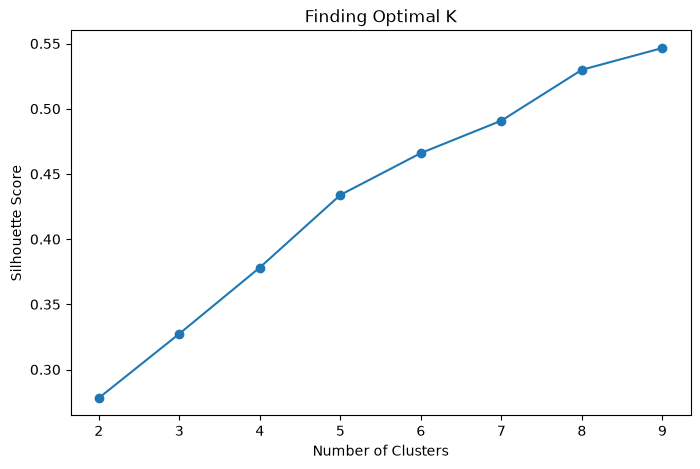

In [8]:
silhouette_scores = []

K_range = range(2,10)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_text)
    
    score = silhouette_score(
        X_text,
        labels
    )
    
    silhouette_scores.append(score)


plt.figure(figsize=(8,5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Finding Optimal K")

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_text)

df.head()

,ID,Age,Vol,combined_text,Cluster
0,1.1.1,9.67,5.0,1.1.1,0
1,1.1.1,19.67,38.0,1.1.1,0
2,1.1.1,29.67,123.0,1.1.1,0
3,1.1.1,39.67,263.0,1.1.1,0
4,1.1.1,49.67,400.0,1.1.1,0


In [10]:
df["Cluster"].value_counts()

Cluster
0    1029
3      71
1      56
2      44
Name: count, dtype: int64

In [11]:
terms = tfidf.get_feature_names_out()

for i, cluster in enumerate(kmeans.cluster_centers_):
    
    print("\nCluster", i)
    
    top_words = cluster.argsort()[-10:]
    
    print(
        [terms[j] for j in top_words]
    )


Cluster 0
['16', '31', '48', '26', '25', '20', '21', '15', '14', '12']

Cluster 1
['20', '21', '22', '23', '24', '25', '26', '19', '48', '11']

Cluster 2
['20', '21', '22', '23', '24', '25', '26', '19', '48', '13']

Cluster 3
['18', '20', '21', '22', '23', '24', '25', '26', '19', '10']


In [12]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_text.toarray()
)

X_pca.shape

(1200, 2)

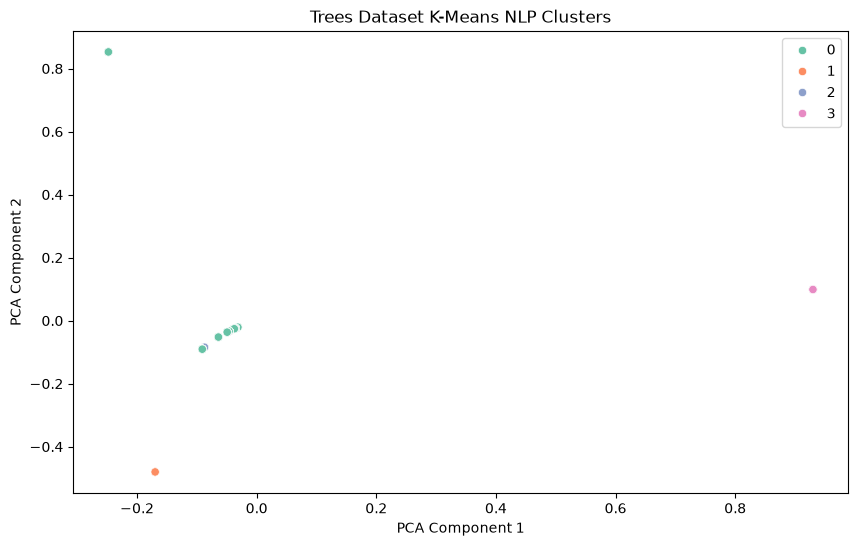

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title(
    "Trees Dataset K-Means NLP Clusters"
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend()

plt.show()

In [14]:
df.to_csv(
    "trees_kmeans_clusters.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!
